# Seq2seq withhout attention vs SeqSeq with Luong attention

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
import sacrebleu
import matplotlib.pyplot as plt
from tqdm import tqdm
import random


In [37]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 4
LR = 1e-4
EMB_DIM = 256
HID_DIM = 512
MAX_LEN = 50
SAMPLES = 60000  

In [38]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
def tokenize(text):
    return text.lower().strip().split()

class Vocab:
    def __init__(self, texts, min_freq=2, max_size=20000):
        from collections import Counter
        counter = Counter(tok for s in texts for tok in tokenize(s))
        common = [w for w, c in counter.items() if c >= min_freq][:max_size]
        self.itos = [PAD, SOS, EOS, UNK] + common
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, text):
        toks = tokenize(text)
        ids = [SOS_IDX]
        for t in toks[:MAX_LEN-2]:
            ids.append(self.stoi.get(t, UNK_IDX))
        ids.append(EOS_IDX)
        return ids

    def decode(self, ids):
        toks = [self.itos[i] for i in ids if i < len(self.itos) and i not in (PAD_IDX, SOS_IDX, EOS_IDX)]
        return " ".join(toks)

In [39]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.data = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pl, en = self.data[idx]
        src = torch.tensor(self.src_vocab.encode(pl))
        tgt = torch.tensor(self.tgt_vocab.encode(en))
        return src, tgt
    
def collate_fn(batch):
    srcs, tgts = zip(*batch)
    srcs = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgts = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return srcs, tgts

In [40]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        emb = self.emb(src)
        outputs, hidden = self.rnn(emb)
        return outputs, hidden

class DecoderNoAttn(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tok, hidden):
        emb = self.emb(input_tok.unsqueeze(1))
        out, hidden = self.rnn(emb, hidden)
        logits = self.fc(out.squeeze(1))
        return logits, hidden

In [41]:
class LuongAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W = nn.Linear(hid_dim, hid_dim, bias=False)

    def forward(self, dec_h, enc_out):
        attn = torch.bmm(enc_out, self.W(dec_h).unsqueeze(2)).squeeze(2)
        attn_weights = torch.softmax(attn, dim=1)
        ctx = torch.bmm(attn_weights.unsqueeze(1), enc_out).squeeze(1)
        return ctx

class DecoderAttn(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
        self.attn = LuongAttention(hid_dim)
        self.fc = nn.Linear(hid_dim*2, vocab_size)

    def forward(self, input_tok, hidden, enc_out):
        emb = self.emb(input_tok.unsqueeze(1))
        out, hidden = self.rnn(emb, hidden)
        ctx = self.attn(out.squeeze(1), enc_out)
        combined = torch.cat([out.squeeze(1), ctx], dim=1)
        logits = self.fc(combined)
        return logits, hidden

In [42]:
def train_epoch(encoder, decoder, loader, opt, criterion, attn=False):
    encoder.train(); decoder.train()
    total_loss = 0
    for src, tgt in tqdm(loader, desc="Train"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        opt.zero_grad()
        enc_out, hidden = encoder(src)
        input_tok = tgt[:, 0]
        loss = 0
        for t in range(1, tgt.size(1)):
            if attn:
                logits, hidden = decoder(input_tok, hidden, enc_out)
            else:
                logits, hidden = decoder(input_tok, hidden)
            loss += criterion(logits, tgt[:, t])
            teacher_force = random.random() < 0.5
            top1 = logits.argmax(1)
            input_tok = tgt[:, t] if teacher_force else top1
        loss /= tgt.size(1)
        if torch.isnan(loss):
            print("NaN detected! Stopping.")
            return total_loss / len(loader)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_bleu(encoder, decoder, loader, src_vocab, tgt_vocab, attn=False):
    encoder.eval(); decoder.eval()
    refs, hyps = [], []

    for src, tgt in tqdm(loader, desc="Eval"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        enc_out, hidden = encoder(src)
        input_tok = torch.full((src.size(0),), SOS_IDX, dtype=torch.long, device=DEVICE)

        generated = [[] for _ in range(src.size(0))]
        for _ in range(MAX_LEN):
            if attn:
                logits, hidden = decoder(input_tok, hidden, enc_out)
            else:
                logits, hidden = decoder(input_tok, hidden)

            top1 = logits.argmax(1)
            input_tok = top1
            for i in range(src.size(0)):
                token = top1[i].item()
                generated[i].append(token)
        for i in range(src.size(0)):
            seq = []
            for tok in generated[i]:
                if tok == EOS_IDX:
                    break
                seq.append(tok)

            hyp = tgt_vocab.decode(seq)
            ref = tgt_vocab.decode(tgt[i].tolist())

            hyps.append(hyp)
            refs.append([ref])

    bleu = sacrebleu.corpus_bleu(hyps, list(zip(*refs)))
    return bleu.score

In [46]:
print("Device:", DEVICE)
ds = load_dataset("Helsinki-NLP/opus-100", "en-pl")
train_pairs = [(ex["translation"]["pl"], ex["translation"]["en"]) for ex in ds["train"].select(range(SAMPLES))]
val_pairs   = [(ex["translation"]["pl"], ex["translation"]["en"]) for ex in ds["validation"]]
test_pairs  = [(ex["translation"]["pl"], ex["translation"]["en"]) for ex in ds["test"]]
 

src_vocab = Vocab([p[0] for p in train_pairs])
tgt_vocab = Vocab([p[1] for p in train_pairs])
train_loader = DataLoader(TranslationDataset(train_pairs[:int(0.9*len(train_pairs))], src_vocab, tgt_vocab),
                              batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(TranslationDataset(train_pairs[int(0.9*len(val_pairs)):], src_vocab, tgt_vocab),
                            batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(TranslationDataset(test_pairs, src_vocab, tgt_vocab),
                             batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

Device: cuda


In [47]:
results = {}
for variant, use_attn in [("no_attn", False), ("luong_attn", True)]:
    print("\nTraining:", variant)
    encoder = Encoder(len(src_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE)
    decoder = DecoderAttn(len(tgt_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE) if use_attn else DecoderNoAttn(len(tgt_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE)
    opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=LR)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    losses, bleus = [], []
    best_bleu = -1
    for ep in tqdm(range(1, EPOCHS+1)):
        loss = train_epoch(encoder, decoder, train_loader, opt, criterion, attn=use_attn)
        bleu = evaluate_bleu(encoder, decoder, val_loader, src_vocab, tgt_vocab, attn=use_attn)
        print(f"Epoch {ep}: loss={loss:.3f} BLEU={bleu:.2f}")
        losses.append(loss)
        bleus.append(bleu)
        if bleu > best_bleu:
            best_bleu = bleu
            torch.save(encoder.state_dict(), f"{variant}_best_encoder.pt")
            torch.save(decoder.state_dict(), f"{variant}_best_decoder.pt")
            print(f"Saved best checkpoint for {variant} (BLEU={bleu:.2f})")
    results[variant] = (losses, bleus)


Training: no_attn


 25%|██▌       | 1/4 [02:37<07:51, 157.14s/it]

Epoch 1: loss=6.512 BLEU=2.63
Saved best checkpoint for no_attn (BLEU=2.63)


 50%|█████     | 2/4 [05:11<05:11, 155.72s/it]

Epoch 2: loss=5.944 BLEU=5.71
Saved best checkpoint for no_attn (BLEU=5.71)


...

Epoch 3: loss=5.720 BLEU=7.80


 75%|███████▌  | 3/4 [09:24<03:08, 188.77s/it]

Saved best checkpoint for luong_attn (BLEU=7.80)


100%|██████████| 4/4 [12:27<00:00, 186.84s/it]

Epoch 4: loss=5.574 BLEU=7.74


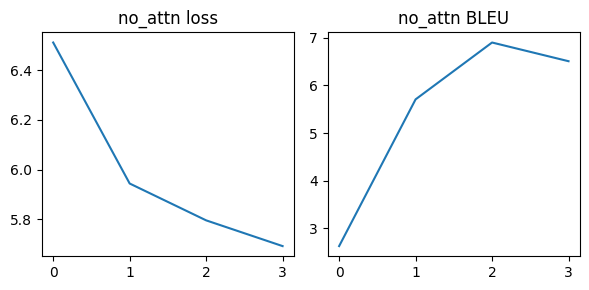

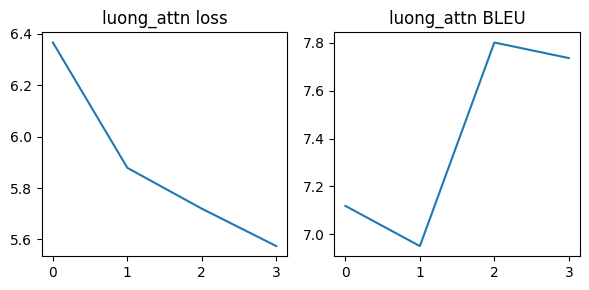

In [48]:
for v, (losses, bleus) in results.items():
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.plot(losses); plt.title(f"{v} loss")
    plt.subplot(1,2,2)
    plt.plot(bleus); plt.title(f"{v} BLEU")
    plt.tight_layout()
    plt.show()

In [49]:
print("\nLoading best models & evaluating on TEST set")
for variant, use_attn in [("no_attn", False), ("luong_attn", True)]:
    encoder = Encoder(len(src_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE)
    decoder = DecoderAttn(len(tgt_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE) if use_attn else DecoderNoAttn(len(tgt_vocab.itos), EMB_DIM, HID_DIM).to(DEVICE)
      
    encoder.load_state_dict(torch.load(f"{variant}_best_encoder.pt"))
    decoder.load_state_dict(torch.load(f"{variant}_best_decoder.pt"))

    test_bleu = evaluate_bleu(encoder, decoder, test_loader, src_vocab, tgt_vocab, attn=use_attn)
    print(f"{variant} TEST BLEU: {test_bleu:.2f}")


Loading best models & evaluating on TEST set


Eval: 100%|██████████| 32/32 [00:03<00:00,  9.07it/s]


no_attn TEST BLEU: 9.13


Eval: 100%|██████████| 32/32 [00:04<00:00,  7.36it/s]

luong_attn TEST BLEU: 10.37


The experiment confirmed that adding classical attention (Luong) to a Seq2Seq model significantly improves PL→EN translation quality. The attention-based model converged faster and achieved a higher BLEU score compared to the non-attention baseline (≈7.8 vs ≈6.9), demonstrating its ability to better leverage source-sentence context during decoding.Although this setup used basic GRU encoder–decoder architecture, further improvements are possible. For example, replacing GRUs with LSTMs to better capture long-range dependencies, increasing model capacity, or applying subword tokenization (e.g., SentencePiece/BPE) would likely improve results.